# Table of Contents

* [1.1 Introduction](#1.1-Introduction)
* [1.2 Preparation](#1.2-Preparation)
    * [1.2.1 Import the dataset](#1.2.1-Import-the-dataset)
* [1.3 Dataset Summary ](#1.3-Dataset-Summary)
* [1.4 Missing Values and Duplicates analysis](#1.4-Missing-Values-and-Duplicates-analysis)
    * [1.4.1 Missing Values](#1.4.1-Missing-Values)
    * [1.4.2 Duplicates](#1.4.2-Duplicates)
* [1.5 Univariate Analysis](#1.5-Univariate-Analysis)
    * [1.5.1 Numerical Variables](#1.5.1-Numerical-Variables)
    * [1.5.2 Outliers Analysis](#1.5.2-Outliers-Analysis)
    * [1.5.3 Categorical Variables](#1.5.3-Categorical-Variables)
* [1.6 Bivariate Analysis](#1.6-Bivariate-Analysis)
    * [1.6.1 Correlation Matrix](#1.6.1-Correlation-Matrix)
    * [1.6.2 Contingency Table](#1.6.2-Contingency-Table)
    * [1.6.3 Notes for Supervised Learning Preprocessing](#1.6.3-Notes-for-Supervised-Learning-Preprocessing)
* [1.7 Final Insights](#1.7-Final-Insights)

# 1.1 Introduction

This notebook performs an Exploratory Data Analysis (EDA) on the `customer_info.csv` dataset. We focus on data quality (missing values, duplicates, outliers) and feature engineering to prepare the data for predictive modeling.

# 1.2 Preparation

Loading necessary libraries and setting plot styles.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import math

## 1.2.1 Import the dataset

In [2]:
file_path = 'C:\\Users\\maria\\Documents\\Universidade\\Machine Learning II\\Customer-Segmentation-Project\\Course Assignment - Customer Segmentation-20260417\\customer_info.csv'
df = pd.read_csv(file_path)
df.head()

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


# 1.3 Dataset Summary

In [3]:
df.dtypes

customer_id                                  int64
customer_name                               object
customer_gender                             object
customer_birthdate                          object
kids_home                                  float64
teens_home                                 float64
number_complaints                          float64
distinct_stores_visited                    float64
lifetime_spend_groceries                   float64
lifetime_spend_electronics                 float64
typical_hour                               float64
lifetime_spend_vegetables                  float64
lifetime_spend_nonalcohol_drinks           float64
lifetime_spend_alcohol_drinks              float64
lifetime_spend_meat                        float64
lifetime_spend_fish                        float64
lifetime_spend_hygiene                     float64
lifetime_spend_videogames                  float64
lifetime_spend_petfood                     float64
lifetime_total_distinct_product

In [4]:
print("\nNumerical Description:")
display(df.describe()) 
print("\nDataset Info:")
df.info()


Numerical Description:


,customer_id,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
count,33038.000000,32708.000000,32708.000000,32377.000000,32708.000000,33038.000000,32377.000000,32377.000000,32377.000000,33038.000000,...,32047.000000,32708.00000,32377.000000,32377.000000,33038.000000,32708.000000,33038.000000,19932.0,33038.000000,33038.000000
mean,19974.265785,1.116118,0.898893,0.930846,3.167941,16306.227798,2763.080088,12.659388,727.223801,464.352776,...,608.781228,820.34646,373.900917,336.217099,148.914644,0.318866,2015.311853,1.0,38.749694,-9.154549
std,11538.538632,1.150186,0.962924,0.894658,1.674114,11985.903518,3453.191495,4.854708,654.633087,275.767976,...,497.068874,608.31732,460.782042,160.234980,105.922907,0.283638,5.032196,0.0,0.022498,0.028581
min,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,-1.274940,1993.000000,1.0,38.687987,-9.232989
25%,9985.250000,0.000000,0.000000,0.000000,2.000000,8647.000000,579.000000,8.000000,224.000000,241.000000,...,171.000000,362.00000,125.000000,225.000000,67.000000,0.122359,2012.000000,1.0,38.734079,-9.173732
50%,19951.500000,1.000000,1.000000,1.000000,3.000000,13002.500000,1470.000000,12.000000,471.000000,421.000000,...,511.000000,686.00000,223.000000,327.000000,123.000000,0.239449,2015.000000,1.0,38.748286,-9.156689
75%,29964.750000,1.000000,1.000000,1.000000,4.000000,20807.000000,3745.000000,16.000000,1074.000000,640.000000,...,923.000000,1120.00000,374.000000,435.000000,210.000000,0.469390,2019.000000,1.0,38.765779,-9.139608
max,40000.000000,8.000000,6.000000,7.000000,10.000000,104670.000000,35299.000000,23.000000,3337.000000,2180.000000,...,3172.000000,3482.00000,3936.000000,1224.000000,600.000000,1.000000,2029.000000,1.0,38.823693,-9.035697



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  object 
 2   customer_gender                          33038 non-null  object 
 3   customer_birthdate                       32873 non-null  object 
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                   

# 1.4 Missing Values and Duplicates analysis

## 1.4.1 Missing Values

In [5]:
null_counts = df.isnull().sum()
missing_df = pd.DataFrame({
    'Missing Values': null_counts
}).sort_values(by='Missing Values', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing Values'] >= 0])

Missing Values Summary:
                                         Missing Values
loyalty_card_number                               13106
lifetime_spend_fish                                 991
lifetime_spend_electronics                          661
lifetime_spend_videogames                           661
lifetime_spend_meat                                 661
lifetime_spend_vegetables                           661
typical_hour                                        661
lifetime_spend_petfood                              661
number_complaints                                   661
distinct_stores_visited                             330
percentage_of_products_bought_promotion             330
teens_home                                          330
lifetime_spend_alcohol_drinks                       330
kids_home                                           330
lifetime_spend_hygiene                              330
customer_birthdate                                  165
year_first_transaction  

## 1.4.2 Duplicates

This section verifies whether the dataset contains repeated entries.
- `df.duplicated().sum()` counts rows that are exactly the same across all columns.
- `df['customer_id'].duplicated().sum()` checks whether the same customer ID appears more than once.

A duplicate customer ID is important because `customer_id` should uniquely identify each customer. If the same ID repeats, the dataset may contain:
- exact duplicate records, or
- conflicting information for the same customer. 

In [6]:
print(f"Full row duplicates: {df.duplicated().sum()}")
print(f"Duplicate Customer IDs: {df['customer_id'].duplicated().sum()}")

Full row duplicates: 0
Duplicate Customer IDs: 0


# 1.5 Univariate Analysis

## 1.5.1 Numerical Variables

In this section, we show the distributions of numerical variables to identify skewness, spread, and potential outliers.

In [20]:
numeric_cols = [
    "kids_home",
    "teens_home",
    "number_complaints",
    "distinct_stores_visited",
    "lifetime_spend_groceries",
    "lifetime_spend_electronics",
    "typical_hour",
    "lifetime_spend_vegetables",
    "lifetime_spend_nonalcohol_drinks",
    "lifetime_spend_alcohol_drinks",
    "lifetime_spend_meat",
    "lifetime_spend_fish",
    "lifetime_spend_hygiene",
    "lifetime_spend_videogames",
    "lifetime_spend_petfood",
    "lifetime_total_distinct_products",
    "percentage_of_products_bought_promotion",
    "year_first_transaction",
    "loyalty_card_number",
    "latitude",
    "longitude"
]

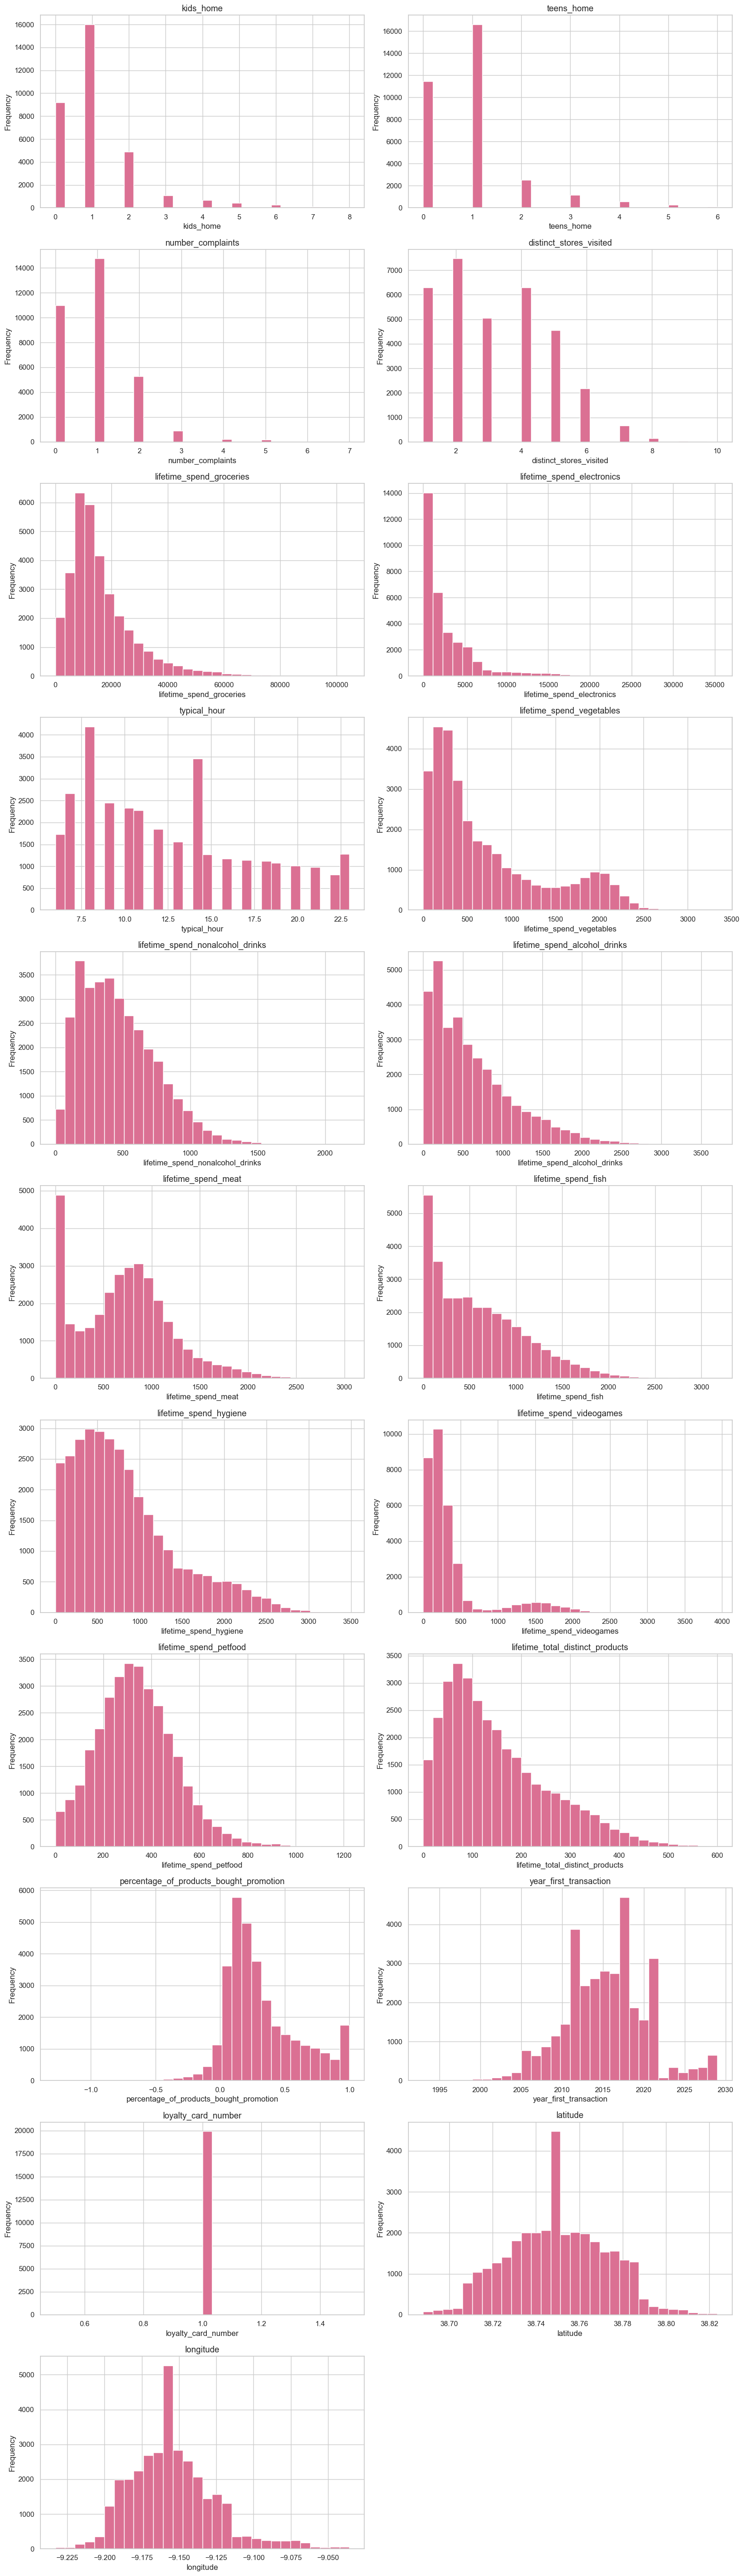

In [24]:
cols_per_row = 2
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / cols_per_row)

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=30, color='palevioletred', ax=axes[i])
    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Esconder eixos vazios se o número de colunas for ímpar
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 1.5.2 Outliers Analysis

This section uses boxplots to visually identify outliers and compare the spread of numerical variables.

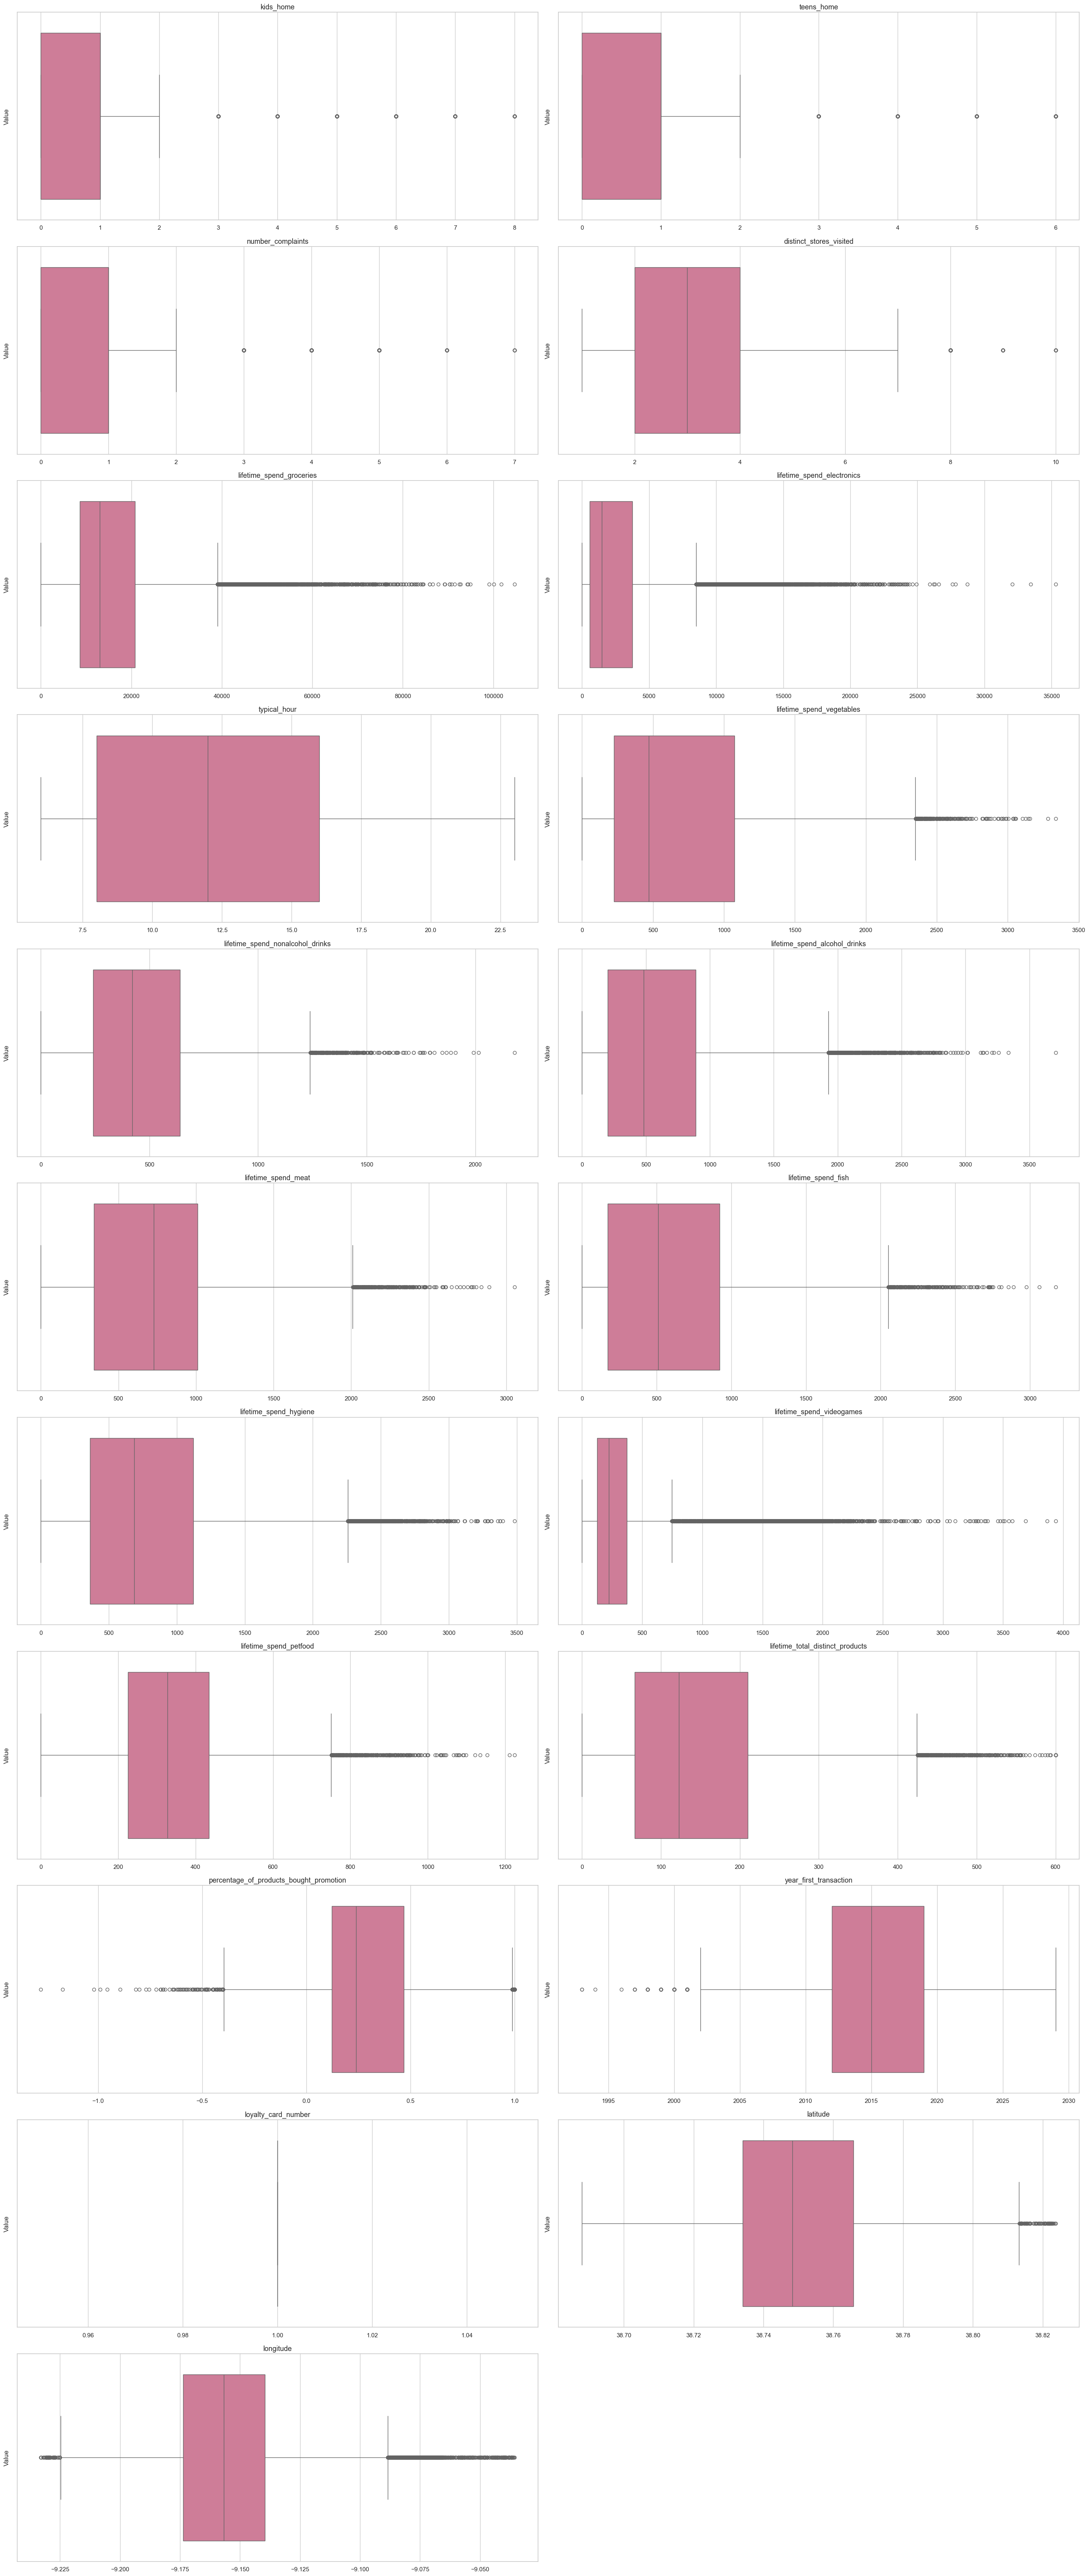

In [30]:
cols_per_row = 2
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / cols_per_row)

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(28, n_rows * 6))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], color='palevioletred', ax=axes[i])
    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Value')

for ax in axes[len(numeric_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 1.5.3 Categorical Variables

### Customer Gender

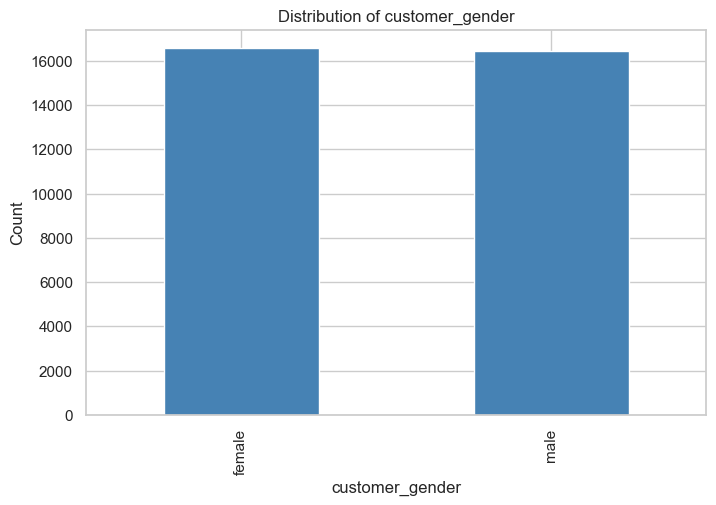

In [36]:
cat_cols = ['customer_gender']
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    df[col].value_counts().plot(kind='bar', color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.ylabel('Count')
    plt.show()

### Customer Birthdate

In this section we convert `customer_birthdate` to a datetime type and extract `birth_month`, `birth_year`, and `birth_day`. Then we visualize the number of customers born in each month to identify seasonal patterns and insights for customer segmentation.

C:\Users\maria\AppData\Local\Temp\ipykernel_23776\2750381356.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='birth_month', data=df, palette='Blues_d')
C:\Users\maria\AppData\Local\Temp\ipykernel_23776\2750381356.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([int(float(label.get_text())) for label in ax.get_xticklabels()])


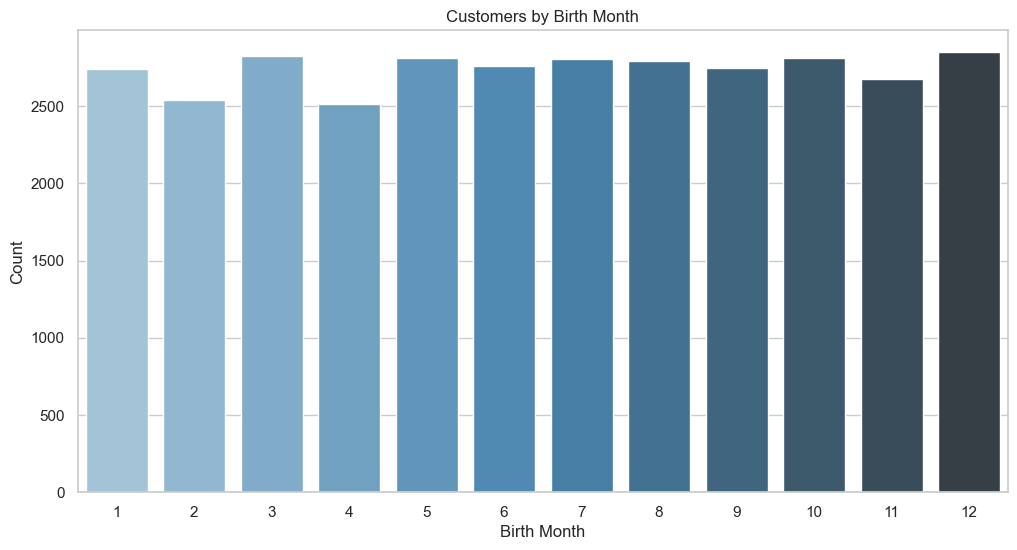

In [35]:
df['customer_birthdate'] = pd.to_datetime(df['customer_birthdate'], errors='coerce')
df['birth_month'] = df['customer_birthdate'].dt.month
df['birth_year'] = df['customer_birthdate'].dt.year
df['birth_day'] = df['customer_birthdate'].dt.day

plt.figure(figsize=(12, 6))
ax = sns.countplot(x='birth_month', data=df, palette='Blues_d')
ax.set_title('Customers by Birth Month')
ax.set_xlabel('Birth Month')
ax.set_ylabel('Count')
ax.set_xticklabels([int(float(label.get_text())) for label in ax.get_xticklabels()])
plt.show()

# 1.6 Bivariate Analysis

## 1.6.1 Correlation Matrix

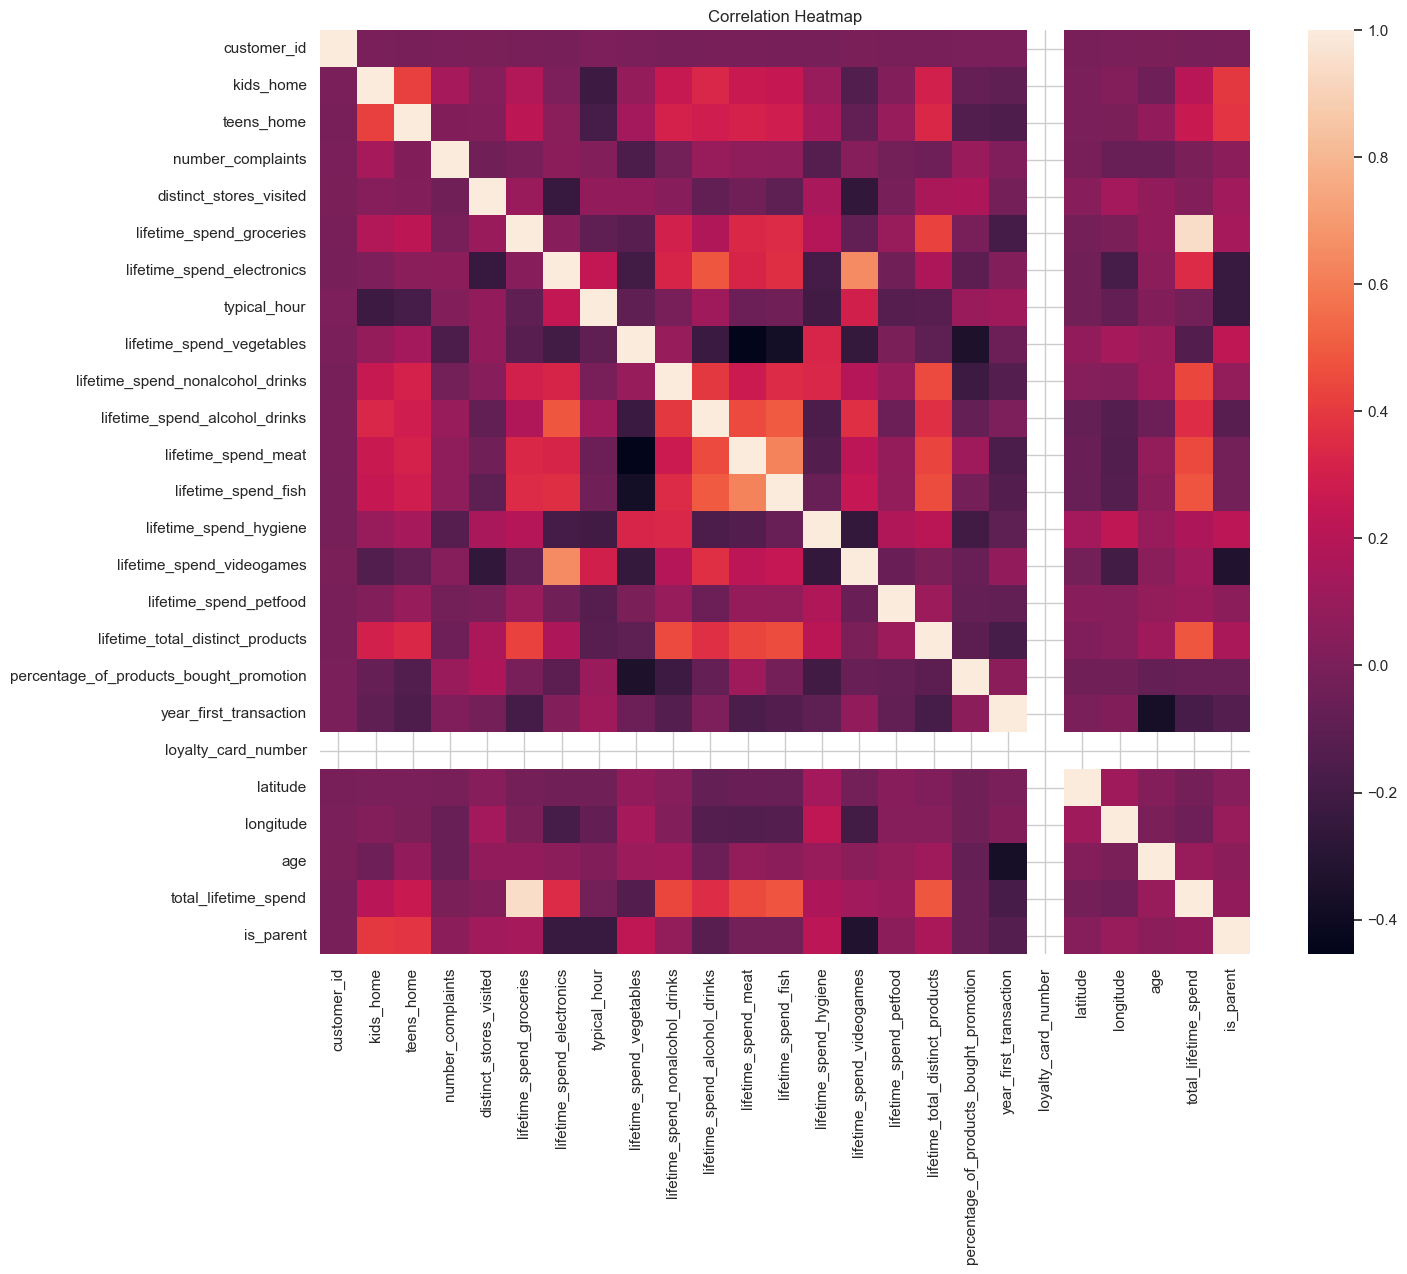

In [ ]:
numerical_df = df.select_dtypes(include=[np.number])
df['birth_month'] = df['customer_birthdate'].dt.month.astype('Int64')
df['birth_year'] = df['customer_birthdate'].dt.year.astype('Int64')
df['birth_day'] = df['customer_birthdate'].dt.day.astype('Int64')
plt.show()

## 1.6.2 Contingency Table

Comparing Categorical variables (e.g., Gender vs Parenting Status).

In [ ]:
contingency_table = pd.crosstab(df['customer_gender'], df['is_parent'])
print("Contingency Table (Gender vs Is Parent):")
print(contingency_table)

Contingency Table (Gender vs Is Parent):
is_parent           0      1
customer_gender             
female           2483  14094
male             2296  14165


## 1.6.3 Notes for Supervised Learning Preprocessing

Since the goal is supervised learning, encoding all categorical variables should be done with caution:

*   **Target Variable**: Handle separately (Label Encoding for classification, raw for regression).
*   **High Cardinality**: Avoid One-Hot Encoding for features with many unique values (e.g., `customer_name`), as it significantly increases dimensionality.
*   **Model Choice**: Tree-based algorithms (Random Forest, XGBoost) often perform better with Ordinal/Label encoding for features with many categories compared to One-Hot Encoding.

# 1.7 Final Insights

The data shows significant right-skewness in spending, requiring non-parametric treatment for outliers. Parenting status and gender show interesting interactions with total lifetime spend, providing strong signals for future segmentation. Selective encoding of categorical features will be crucial in the preprocessing stage to avoid the curse of dimensionality while maintaining predictive power.